In [ ]:
import numpy as np
import pickle
import glob
import os
from torchvision import datasets
from PIL import Image
import bidsio
import matplotlib.pyplot as plt
import importlib
import copy
from matplotlib.ticker import FuncFormatter, MaxNLocator

import sys
sys.path.append('../')
from bandlimited_signal import *
from helpers import *

BIDS_LOADER = bidsio.BIDSLoader(data_entities=[{'subject': '',
                                              'session': '',
                                              'suffix': 'T1w',
                                              'space': 'MNI152NLin2009aSym'}],
                              target_entities=[],
                              data_derivatives_names=['ATLAS'],
                              batch_size=1,
                              root_dir='./atlas/data/test/')

D_EFFECTIVE = { #[grid, ffn, instant-ngp, ga-planes]
    '2d_bandlimited': [128, 44, 7, 115],
    '2d_sphere': [128, 47, 8, 141],
    '2d_div2k': [128, 45, 7, 181],
    '2d_mri': [128, 45, 7, 147]
}

# [1, 10, 1, 10]
BS = { #[grid, ffn, instant-ngp, ga-planes, grid]
    '2d_bandlimited': [1, 10, 1, 10],
    '2d_sphere': [1, 10, 1, 10],
    '2d_div2k': [1, 10, 1, 10],
    '2d_mri': [1, 10, 1, 10],
}

PARAMS_DICT = {
    'ffn': {
        '2d': {
            'mapping_size': 256,
            'num_layers': 1,
        },
        '3d': {
            'mapping_size': 1520,
            'num_layers': 1,
        }
    },
    'instant-ngp': {
        '2d': [{
                'hash_table_size': 12,
                'base_resolution': 16,
            },
            {
                'hash_table_size': 11,
                'base_resolution': 64,
            }],
        '3d': {
            'hash_table_size': 16,
            'base_resolution': 16,
        }
    },
    'ga-planes': {
        '2d': {
            'lineres': 128,
            'planeres': 2,
            'plane_feature_dim': 1,
        },
        '3d': {
            'lineres': 64,
            'planeres': 64,
            'volumeres': 2,
            'volume_feature_dim': 1,
        }
    },
}

In [ ]:
def load_model_args(task_name, model_name, val):
    dimension, dataset = task_name.split('_')
    if model_name == 'ffn':
        model_args = copy.deepcopy(PARAMS_DICT[model_name][dimension])
        model_args['width'] = val
        return model_args
    elif model_name == 'instant-ngp':
        if dimension == '2d':
            if dataset in ['sphere', 'bandlimited']: entry = PARAMS_DICT[model_name][dimension][0]
            else: entry = PARAMS_DICT[model_name][dimension][1]
        else:
            entry = PARAMS_DICT[model_name][dimension]
        model_args = {}
        model_args['mlp_config'] = (2, 64)
        model_args['model_config'] = (val, entry['hash_table_size'], entry['base_resolution'], 2.0)
        return model_args
    elif model_name == 'ga-planes':
        model_args = copy.deepcopy(PARAMS_DICT[model_name][dimension])
        if dimension == '2d':
            model_args['line_feature_dim'] = val
        else:
            model_args['line_feature_dim'] = val
            model_args['plane_feature_dim'] = val
        return model_args
    elif model_name == 'grid':
        model_args = {}
        model_args['grid_reso'] = val
        return model_args
    return None

def load_gt(model_name, task_name):
    dimension, dataset = task_name.split('_')
    dimension = int(dimension[0])

    if dimension == 2:
        RES = 128
    else:
        RES = 64

    if dataset in ['sphere', 'bandlimited']:
        id_val = 1234
    else:
        id_val = 131

    if dataset=='div2k':
        signal_pil = Image.open(f'./DIV2K/DIV2K_train_LR_x8/0{str(id_val)}x8.png')
        signal = np.array(signal_pil.convert('L').resize((RES, RES))) / 255.0 
    elif dataset == 'sphere':
        signal = SparseSphereSignal(dimension=dimension, length=RES, bandlimit=0.3, seed=id_val, generate=False).signal
    elif dataset == 'bandlimited':
        signal = BandlimitedSignal(dimension=dimension, length=RES, bandlimit=0.9, seed=id_val, generate=False).signal
    elif dataset == 'dragon':
        signal =  resize(Voxel_Fitting(dimension=3, length=RES, bandlimit=0.6, seed=id_val, super_resolution=False, sparse=True).signal, (RES, RES, RES))
    elif dataset == 'mri' and dimension == 2:
        tmp = BIDS_LOADER.load_sample(idx = id_val, data_only=True) / 255.0
        vol = resize(tmp, (1, RES, RES, RES))[0]
        rng = np.random.default_rng(0)
        slice_idx = rng.integers(0, RES)
        signal = vol[:, :, slice_idx]  # (RES, RES)
    elif dataset == 'mri' and dimension == 3:
        tmp = BIDS_LOADER.load_sample(idx = id_val, data_only=True) / 255.0
        signal = resize(tmp, (1, RES, RES, RES))[0]
    else:
        raise ValueError(f"Dataset {dataset} not supported.")
    return signal


def fit_c(optimal_errors, bounds, params, d_star):
    d = np.asarray(params, dtype=float)
    u = np.asarray(bounds, dtype=float)
    err = np.asarray(optimal_errors, dtype=float)

    denom = d_star - d
    ratios = err * denom / (u)
    c_min = float(np.max(ratios))
    bounds_min = u * c_min/ denom

    return c_min, bounds_min

def compute_c(model_name, task_name, model_index, start_i=0, use_eta=True):  
  dimension, dataset = task_name.split('_')
  dimension = int(dimension[0])
  if dimension == 2:
    b = BS[task_name][model_index]
    d_star = D_EFFECTIVE[task_name][model_index]
  else:
    b = 1

  with open(f'./results/{task_name}/{model_name}_eta.pkl', 'rb') as f:
        exp_dict = pickle.load(f)
  
  flattened_gt = load_gt(model_name, task_name).flatten()

  param_vals = [int(ind) for ind in exp_dict.keys()]
  param_vals = param_vals[start_i:]
  if dimension == 3: d_star = param_vals[-1]
  m = len(param_vals)
  assert b <= m, f"b={b} must be less than or equal to number of params={m}"
  last_index = min(m-b, d_star - param_vals[0])  # Ensure we don't go beyond d_star
  # last_index = m - b  # We can only compute bounds for the first m-b params

  # Compute optimal errors
  optimal_errors = []
  for i in range(last_index):
      exp = exp_dict[str(param_vals[i])]
      optimal_errors.append(np.linalg.norm(flattened_gt - exp['pred']))
    #   optimal_errors.append(exp['error'])
#   print(optimal_errors)

  # Compute upper bound with optimization gap from approach 4
  bounds_eta_block = []
  for i in range(last_index):
      exps = [exp_dict[str(param_vals[j])] for j in range(i, i + b + 1)]
      d = param_vals[i]
      first_term = [np.linalg.norm(exps[j]['pred'] - exps[j + 1]['pred']) for j in range(b)]
      first_term = (d_star - d) * sum(first_term) / len(first_term)
      second_term = [np.linalg.norm(exps[j]['eta'] - exps[j + 1]['eta']) for j in range(b)]
      second_term = (d_star - d) * sum(second_term) / len(second_term)
      bound_eta_block = first_term + second_term + exps[0]['eta_upper_bound']
      bounds_eta_block.append(bound_eta_block)


  # Compute upper bound without optimization gap block-based
  bounds_no_eta_block = []
  for i in range(last_index):
    exps = [exp_dict[str(param_vals[j])] for j in range(i, i + b + 1)]
    d = param_vals[i]
    first_term = [np.linalg.norm(exps[j]['pred'] - exps[j + 1]['pred']) for j in range(b)]
    first_term = (d_star - d) * sum(first_term) / len(first_term)
    bounds_no_eta_block.append(first_term)
  
  if use_eta:
    bound_to_fit = bounds_eta_block
  else:
    bound_to_fit = bounds_no_eta_block

  c, bounds = fit_c(optimal_errors, bound_to_fit, param_vals[:last_index], d_star)
  return {
        'optimal_errors': optimal_errors,
        'true_bound': bound_to_fit,
        'c': c, 
        'fitted_bound': bounds,
        'param_vals': param_vals[:last_index],
        'd_star': d_star,
    }

MODELS = {'grid': 'Grid', 'ffn': 'FFN', 'instant-ngp': 'Instant-NGP', 'ga-planes': 'GA-Planes'}
TASK_NAME_DICT = {
    '2d_bandlimited': '2D Bandlimited',
    '2d_sphere': '2D Sphere',
    '2d_div2k': '2D DIV2K',
    '2d_mri': '2D MRI',
    '3d_bandlimited': '3D Bandlimited',
    '3d_sphere': '3D Sphere',
    '3d_dragon': '3D Dragon',
    '3d_mri': '3D MRI',
}

def plot_global_error_curves(tasks, save_name='global_error_curves', mode='horizontal', use_eta=True):
    n_models, n_tasks = len(MODELS), len(tasks)

    if mode == 'vertical':
        n_rows, n_cols = n_tasks, n_models
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols + 0.5, 3*n_rows + 0.5))
    else:
        n_rows, n_cols = n_models, n_tasks
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols + 0.5, 3*n_rows + 0.5))
    axs = np.atleast_2d(axs)

    for i, model_name in enumerate(MODELS.keys()):
        for j, task_name in enumerate(tasks):
            if mode == 'vertical':
                ax = axs[j, i]
                row, col = j, i
            else:
                ax = axs[i, j]
                row, col = i, j

            dimension, dataset = task_name.split('_')
            dimension = int(dimension[0])
            gt_size = 128*128 if dimension == 2 else 64*64*64

            res = compute_c(model_name, task_name, i, use_eta=use_eta)
            pv           = np.asarray(res['param_vals'], dtype=float)
            opt_errors   = np.asarray(res['optimal_errors'])
            true_bound   = np.asarray(res['true_bound'])
            c            = res['c']
            d_star       = res['d_star']
            c = CS[model_name]
            fitted_bound = c * true_bound / (d_star - pv)

            model_sizes        = np.array([compute_model_size(f'{model_name}_eta', load_model_args(task_name, model_name, int(p)), n_dims=dimension) for p in pv])
            compression_ratios = model_sizes / gt_size

            if dimension == 2:
                d_star_cr = compute_model_size(f'{model_name}_eta', load_model_args(task_name, model_name, d_star)) / gt_size
                if model_name == 'instant-ngp':
                    cr_grid = compression_ratios[compression_ratios <= d_star_cr]
                else:
                    cr_grid = np.arange(
                        np.floor(compression_ratios[0] / 0.05) * 0.05,
                        d_star_cr + 1e-9,
                        0.05,
                    )
                indices = np.array([np.argmin(np.abs(compression_ratios - cr)) for cr in cr_grid])
                opt_errors_i   = opt_errors[indices]
                fitted_bound_i = fitted_bound[indices]
                true_bound_i   = true_bound[indices]
            else:
                cr_grid = compression_ratios
                indices = np.array([np.argmin(np.abs(compression_ratios - cr)) for cr in cr_grid])
                opt_errors_i   = opt_errors[indices]
                fitted_bound_i = fitted_bound[indices]
                true_bound_i   = true_bound[indices]

            l1, = ax.plot(cr_grid, opt_errors_i, label='Actual error', marker='o', markersize=3)
            l2, = ax.plot(cr_grid, fitted_bound_i, label=f'Predicted error', linestyle='--', marker='s',  markersize=3)

            ax_r = ax.twinx()
            l3, = ax_r.plot(cr_grid, true_bound_i,
                            label='Theoretical error bound', color='C2', linestyle='-.',
                            marker='^', markersize=3)
            ax_r.tick_params(axis='y', labelcolor='C2')

            fmt = FuncFormatter(lambda x, _: f'{x:.0f}' if x == int(x) else f'{x:.1f}')

            ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
            ax.yaxis.set_major_formatter(fmt)
            ax_r.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
            ax_r.yaxis.set_major_formatter(fmt)

            if col == 0:
                ax.set_ylabel('ℓ₂ error', fontsize=14)
            if col == n_cols - 1:
                ax_r.set_ylabel('Theoretical bound', color='C2', fontsize=14)

            if mode == 'vertical':
                if row == 0:
                    ax.set_title(MODELS[model_name], fontsize=14)
                if col == 0:
                    # ax.text(-0.37, 0.5, TASK_NAME_DICT[task_name], va='center', ha='right',
                    #         rotation='vertical', fontsize=14, transform=ax.transAxes)
                    # ax.text(-0.20, 0.5, TASK_NAME_DICT[task_name], va='center', ha='right', rotation='vertical', fontsize=14, transform=ax.transAxes) #task 2
                    ax.text(-0.22, 0.5, TASK_NAME_DICT[task_name], va='center', ha='right', rotation='vertical', fontsize=14, transform=ax.transAxes) #task 1
            else:
                if row == 0:
                    ax.set_title(TASK_NAME_DICT[task_name], fontsize=14)
                if col == 0:
                    ax.text(-0.19, 0.5, MODELS[model_name], va='center', ha='right',
                            rotation='vertical', fontsize=14, transform=ax.transAxes)

            # ax.legend(handles=[l1, l2, l3], fontsize=10, loc='upper right')
            ax.grid(False)
    if mode == 'horizontal':
        fig.text(0.5, 0.01, 'Compression Level', ha='center', fontsize=14)
    else:
        # fig.text(0.5, -0.01, 'Compression Level', ha='center', fontsize=14) #task 2
        # fig.text(0.5, 0.05, 'Compression Level', ha='center', fontsize=14) #task 1
        fig.text(0.5, 0.04, 'Compression Level', ha='center', fontsize=14) #appendix
    # fig.legend(handles=[l1, l2, l3], labels=['Actual error', 'Predicted error', 'Theoretical error bound'], loc='lower center', fontsize=12, frameon=True, ncols=3, bbox_to_anchor=(0.5, -0.1)) #task 2
    # fig.legend(handles=[l1, l2, l3], labels=['Actual error', 'Predicted error', 'Theoretical error bound'], loc='lower center', fontsize=12, frameon=True, ncols=3, bbox_to_anchor=(0.5, 0.02)) #task 1
    fig.legend(handles=[l1, l2, l3], labels=['Actual error', 'Predicted error', 'Theoretical error bound'], loc='lower center', fontsize=12, frameon=True, ncols=3, bbox_to_anchor=(0.5, -0.01)) #appendix


    fig.subplots_adjust(left=0.06, right=0.94, top=0.95, bottom=0.08, wspace=0.33, hspace=0.10)
    # fig.subplots_adjust(left=0.06, right=0.85, top=0.95, bottom=0.06, wspace=0.55, hspace=0.10)
    # fig.subplots_adjust(left=0.06, right=0.94, top=0.95, bottom=0.06, wspace=0.25, hspace=0.10)
    # fig.subplots_adjust(left=0.06, right=0.94, top=0.95, bottom=0.06, wspace=0.45, hspace=0.10)
    if mode == 'vertical':
        fig.savefig(f'{save_name}_{mode}.pdf', bbox_inches='tight', dpi=150)
    else: 
        fig.savefig(f'{save_name}.pdf', bbox_inches='tight', dpi=150)
    plt.show()

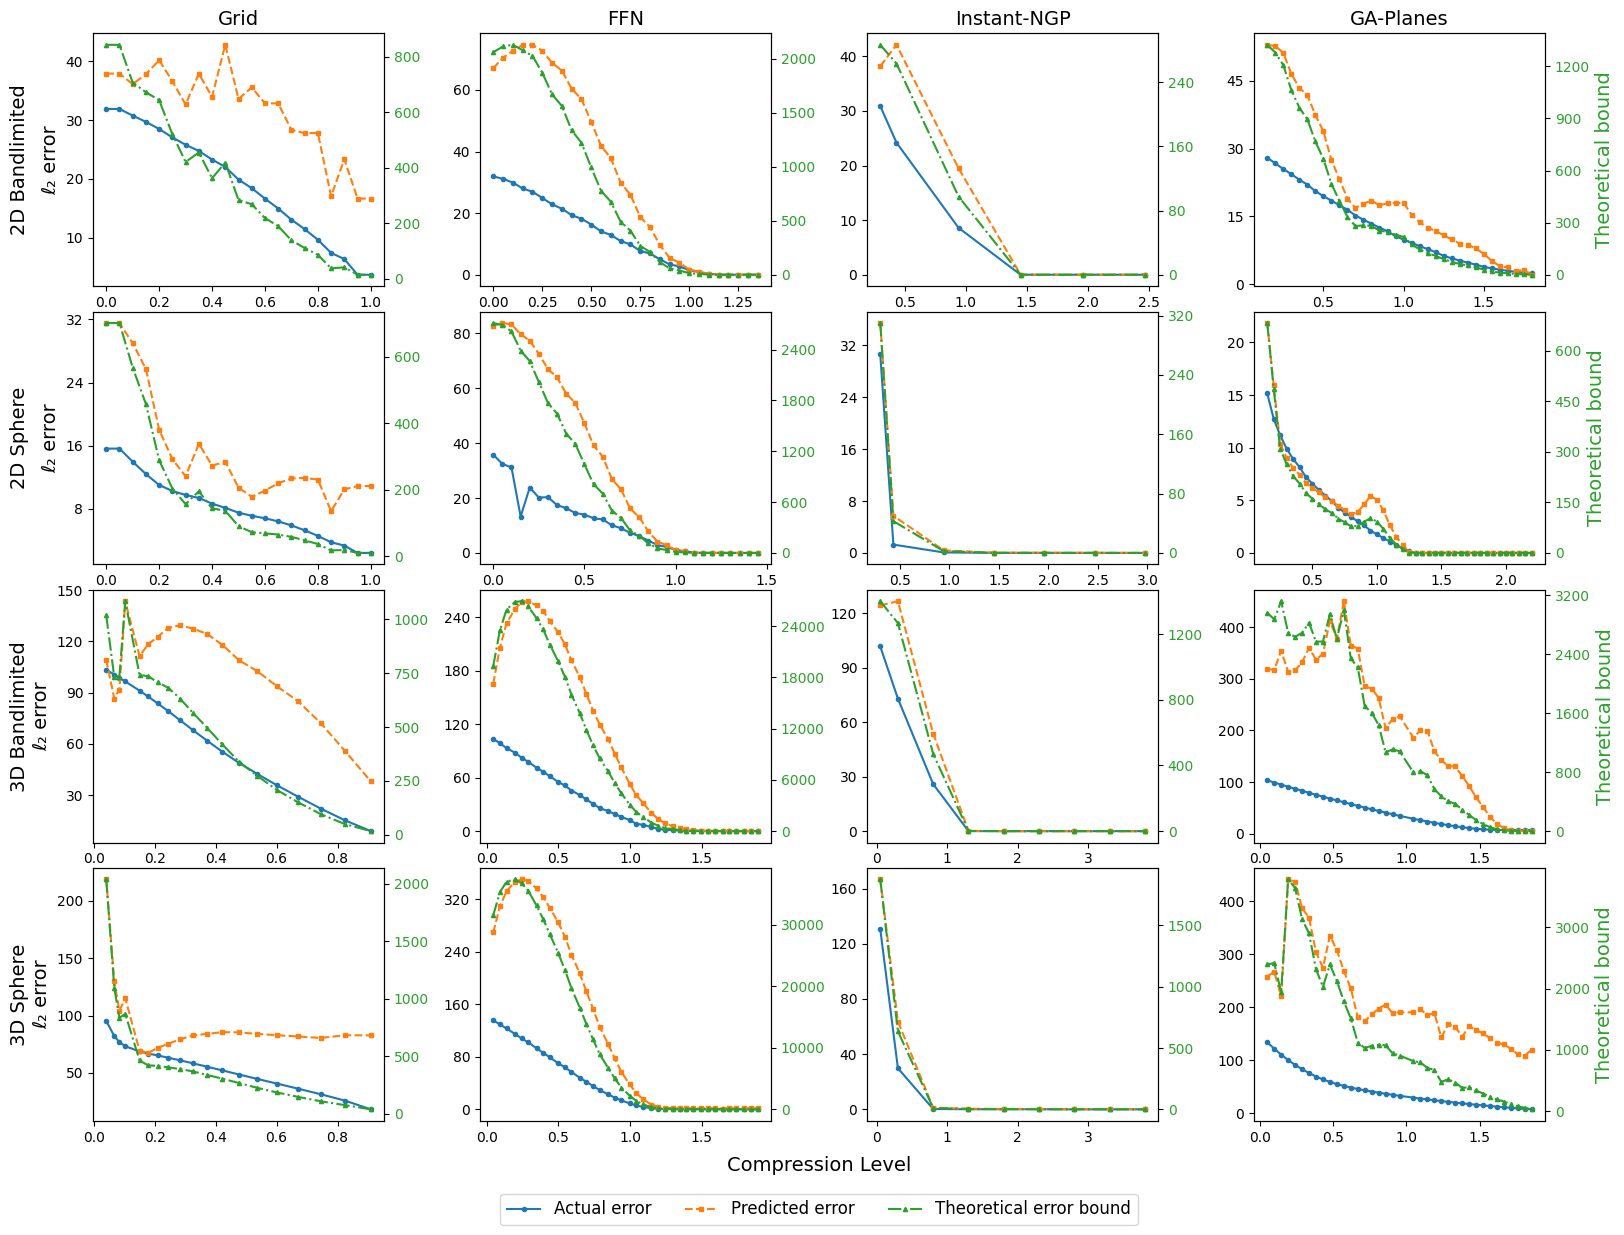

In [13]:
tasks = ['2d_bandlimited', '2d_sphere', '3d_bandlimited', '3d_sphere']
plot_global_error_curves(tasks, 'task1_global_error_curves_appendix', mode='vertical', use_eta=True)

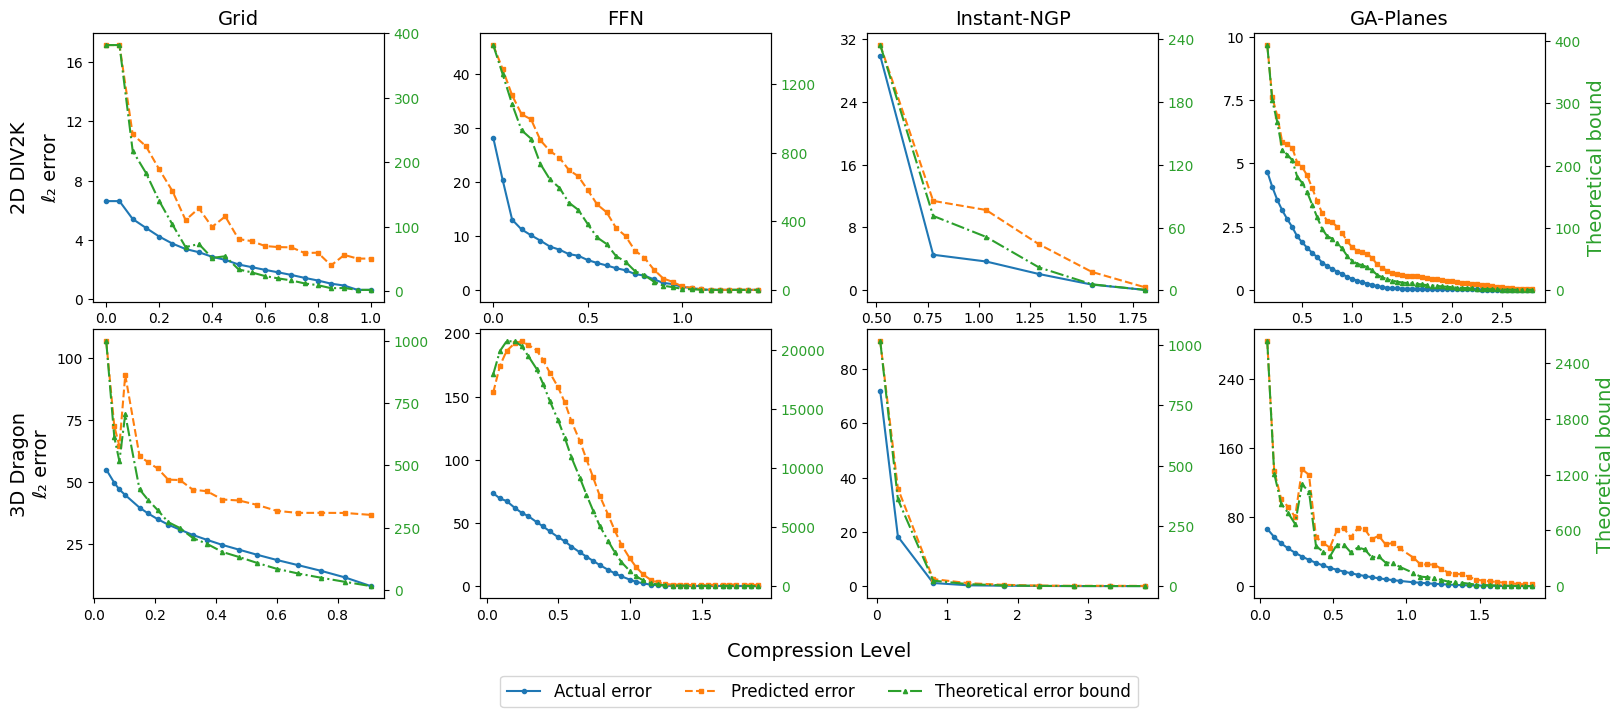

In [6]:
tasks = ['2d_div2k', '3d_dragon']
plot_global_error_curves(tasks, 'task1_global_error_curves_nosyn', mode='vertical', use_eta=True)

{'13': {'eta': array([[[2.24996940e-03, 1.74083735e-03, 1.49135548e-03],
        [3.63940198e-04, 2.18666878e-06, 7.99866870e-16],
        [5.65748337e-07, 3.29665886e-20, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.83415895e-11, 1.05156239e-40, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[4.33386838e-08, 1.53932659e-25, 0.00000000e+00],
        [3.05882963e-09, 4.13295632e-31, 0.00000000e+00],
        [4.85778054e-16, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.73576247e-08, 1.92598483e-27, 0.00000000e+00]],

       [[9.07130074e-04, 8.74819001e-04, 7.53768894e-04],
        [6.24788132e-09, 1.48395611e-29, 0.00000000e+00],
        [5.00366377e-06, 1.18344902e-15, 0.00000000e+00],
        ...,
        [8.09177170e-09, 5.05437925e-29, 0.00000000e+00],
        [1.892

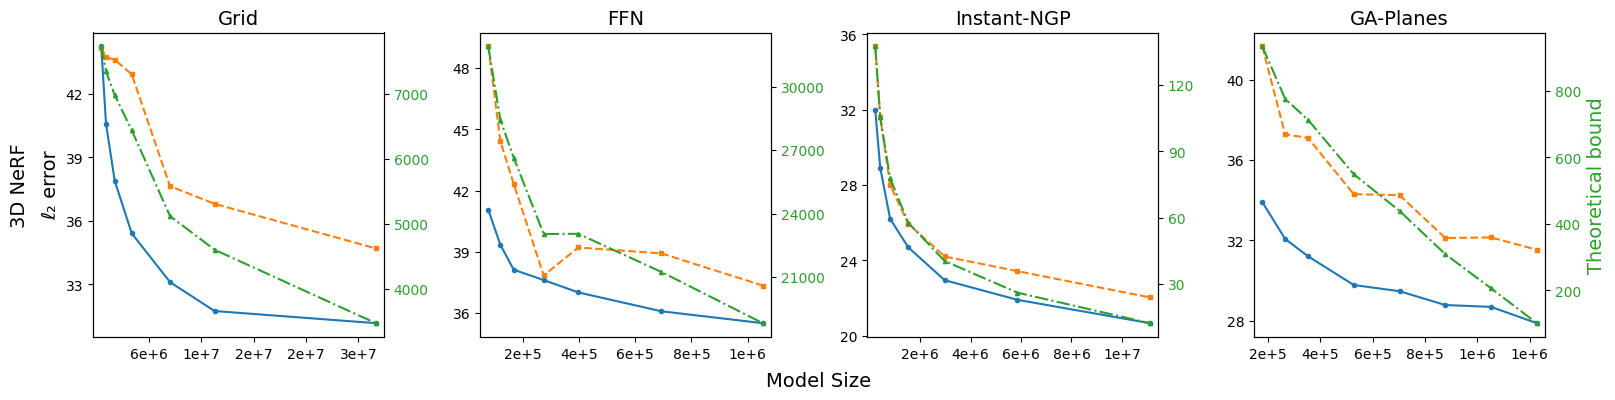

In [ ]:
def compute_c_nerf(model_name, start_i=0):  
  d_stars_dict = {
      'grid': 400,
      'ffn': 2048,
      'instant-ngp': 20,
      'ga-planes': 64,
  }
  d_star = d_stars_dict[model_name]
  b = 1

  with open(f'./results/3d_nerf/{model_name}_eta.pkl', 'rb') as f:
        exp_dict = pickle.load(f)

  param_vals = [int(ind) for ind in exp_dict.keys()]
  if model_name == 'grid':  param_vals = sorted(param_vals)
  param_vals = param_vals[start_i:]
  m = len(param_vals)
  assert b <= m, f"b={b} must be less than or equal to number of params={m}"
  last_index = min(m-b, d_star - param_vals[0])  # Ensure we don't go beyond d_star

  # Compute optimal errors
  optimal_errors, model_sizes = [], []
  for i in range(last_index):
      exp = exp_dict[str(param_vals[i])]
      model_sizes.append(exp['model_size'])
      optimal_errors.append(exp['error'])


  # Compute upper bound without optimization gap block-based
  bounds_no_eta_block = []
  for i in range(last_index):
    exps = [exp_dict[str(param_vals[j])] for j in range(i, i + b + 1)]
    d = param_vals[i]
    first_term = [np.linalg.norm(exps[j]['pred'] - exps[j + 1]['pred']) for j in range(b)]
    first_term = (d_star - d) * sum(first_term) / len(first_term)
    bounds_no_eta_block.append(first_term)

  c, bounds = fit_c(optimal_errors, bounds_no_eta_block, param_vals[:last_index], d_star)
  return {
        'optimal_errors': optimal_errors,
        'true_bound': bounds_no_eta_block,
        'c': c, 
        'fitted_bound': bounds,
        'param_vals': param_vals[:last_index],
        'd_star': d_star,
        'model_sizes': model_sizes,
    }

MODELS = {'grid': 'Grid', 'ffn': 'FFN', 'instant-ngp': 'Instant-NGP', 'ga-planes': 'GA-Planes'}

def plot_global_error_curves_nerf(save_name='global_error_curves'):
    n_cols = len(MODELS)

    fig, axs = plt.subplots(1, n_cols, figsize=(4*n_cols + 0.5, 3 + 0.5))
    axs = np.atleast_1d(axs)

    for i, model_name in enumerate(MODELS.keys()):
        ax = axs[i]
        col = i

        res = compute_c_nerf(model_name)
        pv           = np.asarray(res['param_vals'], dtype=float)
        opt_errors   = np.asarray(res['optimal_errors'])
        true_bound   = np.asarray(res['true_bound'])
        c            = res['c']
        d_star       = res['d_star']
        model_sizes = res['model_sizes']
        c = CS[model_name]
        fitted_bound = c * true_bound / (d_star - pv)

        l1, = ax.plot(model_sizes, opt_errors, label='Actual error', marker='o', markersize=3)
        l2, = ax.plot(model_sizes, fitted_bound, label=f'Predicted error', linestyle='--', marker='s',  markersize=3)

        ax_r = ax.twinx()
        l3, = ax_r.plot(model_sizes, true_bound,
                        label='Theoretical error bound', color='C2', linestyle='-.',
                        marker='^', markersize=3)
        ax_r.tick_params(axis='y', labelcolor='C2')

        fmt = FuncFormatter(lambda x, _: f'{x:.0f}' if x == int(x) else f'{x:.1f}')

        ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
        ax.yaxis.set_major_formatter(fmt)
        ax_r.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
        ax_r.yaxis.set_major_formatter(fmt)


        def sci_tick_fmt(x, pos=None):
            """Format ticks as 1e+6, 3e+5, etc."""
            if x == 0:
                return "0"
            s = f"{x:.0e}"          # e.g. 1e+06
            s = s.replace("e+0", "e+").replace("e-0", "e-")
            return s
        xmin, xmax = min(model_sizes), max(model_sizes)
        pad = 0.03 * (xmax - xmin)

        ax.set_xlim(xmin - pad, xmax + pad)

        ax.xaxis.set_major_locator(MaxNLocator(nbins=6, prune='both'))
        ax.xaxis.set_major_formatter(FuncFormatter(sci_tick_fmt))
        ax.xaxis.get_offset_text().set_visible(False)

        ticks = ax.get_xticks()
        ticks = [t for t in ticks if t > 0]
        ax.set_xticks(ticks)

        if col == 0:
            ax.set_ylabel('ℓ₂ error', fontsize=14)
            ax.text(-0.22, 0.5, '3D NeRF', va='center', ha='right',
                    rotation='vertical', fontsize=14, transform=ax.transAxes)
        if col == n_cols - 1:
            ax_r.set_ylabel('Theoretical bound', color='C2', fontsize=14)

        ax.set_title(f'{MODELS[model_name]}', fontsize=14)
        ax.grid(False)
    
    fig.text(0.5, -0.06, 'Model Size', ha='center', fontsize=14) 

    fig.subplots_adjust(left=0.06, right=0.94, top=0.95, bottom=0.08, wspace=0.33, hspace=0.10)
    fig.savefig(f'{save_name}.pdf', bbox_inches='tight', dpi=150)
    plt.show()

plot_global_error_curves_nerf('3d_nerf_global_error_curves')